# 5. Modelado no supervisado

## 5.1 Objetivo

Explorar la estructura de las características musicales mediante técnicas de aprendizaje no supervisado. Para ello se emplean análisis de componentes principales (ACP) y clustering con K-Means, con el objetivo de identificar patrones y grupos de canciones con características similares.

## 5.2 Carga y selección de variables

In [2]:
from pathlib import Path
import sys

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [3]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from prince import PCA as PCA_Prince
import matplotlib.pyplot as plt
from src.plotting import graficar_circulo_correlacion

Se seleccionan las variables numéricas que describen las características musicales de las canciones. La variable objetivo (popularity) se excluye del análisis para que la formación de grupos dependa únicamente de las similitudes entre las canciones. Las variables se estandarizan para evitar que las diferencias de escala influyan en el análisis.

In [4]:
df = pd.read_csv("../data/processed/spotify_clean.csv")

numerical_features = ["duration_ms","danceability", "energy", "loudness", "speechiness", 
                    "acousticness", "instrumentalness", "liveness", "valence", "tempo"]

X_cluster = df[numerical_features].copy()

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

X_scaled = pd.DataFrame(X_scaled, columns=X_cluster.columns, index=X_cluster.index)

## 5.3 Análisis de componentes principales (ACP)

Se aplica un ACP para explorar la estructura multivariada de las características musicales y evaluar en qué medida la información original puede representarse mediante un número menor de componentes.

In [5]:
pca = PCA_Prince(n_components=X_scaled.shape[1])
pca.fit(X_scaled)

,n_components,10
,rescale_with_mean,True
,rescale_with_std,True
,n_iter,3
,copy,True
,check_input,True
,random_state,None
,engine,'sklearn'
Name,Type,Value
column_contributions_,DataFrame,component ...71 0.000030
column_coordinates_,DataFrame,component ...22 0.002045


In [6]:
explained_variance = pca.percentage_of_variance_
cumulative_variance = np.cumsum(explained_variance)

pca_variance = pd.DataFrame({
    "Component": range(1, len(explained_variance) + 1),
    "Explained variance (%)": explained_variance,
    "Cumulative variance (%)": cumulative_variance
})

pca_variance

,Component,Explained variance (%),Cumulative variance (%)
0,1,28.738924,28.738924
1,2,15.239652,43.978576
2,3,12.340209,56.318785
3,4,9.711018,66.029803
4,5,8.868239,74.898041
5,6,8.336081,83.234122
6,7,7.479463,90.713586
7,8,4.631635,95.345221
8,9,3.254106,98.599327
9,10,1.400673,100.000000


Las primeras dos componentes explican aproximadamente el 43.98% de la variabilidad total de los datos. Para conservar al menos el 90% de la información, serían necesarias 7 componentes, que aproximadamente acumulan el 90.71%.

Las primeras dos componentes se utilizan principalmente con fines de visualización y no representan la totalidad de la información contenida en las variables originales.

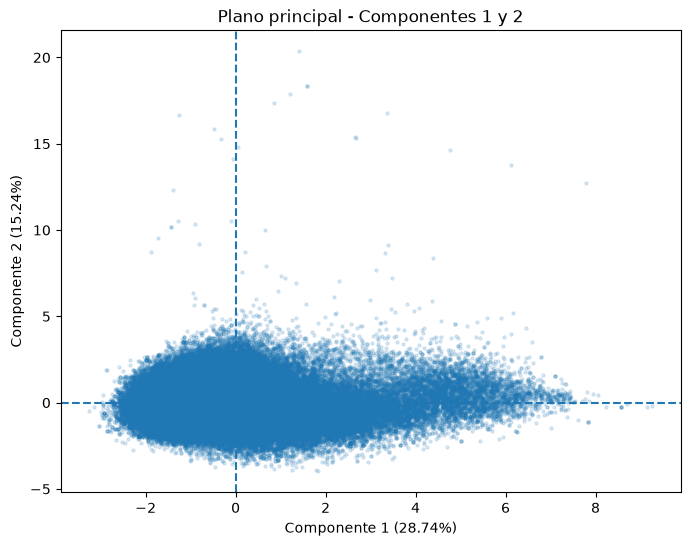

In [7]:
individuals = pca.row_coordinates(X_scaled)
plt.figure(figsize=(8, 6))

plt.scatter(
    individuals.iloc[:, 0],
    individuals.iloc[:, 1],
    alpha=0.15,
    s=5
)

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel(f"Componente 1 ({pca.percentage_of_variance_[0]:.2f}%)")
plt.ylabel(f"Componente 2 ({pca.percentage_of_variance_[1]:.2f}%)")
plt.title("Plano principal - Componentes 1 y 2")

plt.show()

En el plano formado por las primeras dos componentes no se observa una separación clara en grupos distintos.  Aunque existen regiones con mayor concentración de canciones, estas se superponen entre sí, por lo que no es posible identificar agrupamientos de forma visual.

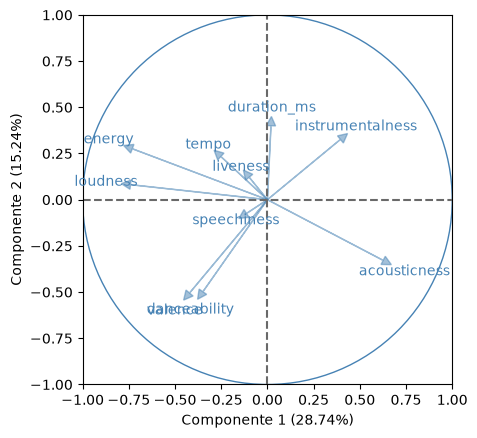

In [8]:
variables = pca.column_correlations

x = variables.iloc[:, 0] * 0.95
y = variables.iloc[:, 1] * 0.95

inercia_x = pca.percentage_of_variance_[0]
inercia_y = pca.percentage_of_variance_[1]

etiquetas = variables.index

graficar_circulo_correlacion(
    x,
    y,
    inercia_x,
    inercia_y,
    etiquetas=etiquetas,
    comp_x=1,
    comp_y=2,
    titulo_x="Componente",
    titulo_y="Componente"
)

En el círculo de correlaciones se observa que energy y loudness presentan una fuerte relación positiva, mientras que acousticness muestra una relación negativa entre ambas variables. Asimismo, danceability y valence apuntan en una dirección similar, lo que sugiere que ambas presentan un comportamiento parecido en las dos primeras componentes principales. Por orto lado, variables como speechiness, liveness y tempo se encuentran más cerca al origen, por lo que su relación con las primeras dos componentes es menor.

## 5.4 Clustering con K-Medias

Una vez explorada la estructura de los datos mediante ACP, se aplica K-Medias para identificar grupos de canciones con características musicales similares.

In [9]:
X_cluster = df[numerical_features].copy()

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

### Selección del número de clústeres

Para seleccionar el número adecuado de clústeres se evaluaron distintos valores de k mediante el método del codo y el coeficiente de silhouette.

In [10]:
inercias = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, n_init=10)
    
    kmeans.fit(X_cluster_scaled)
    inercias.append(kmeans.inertia_)

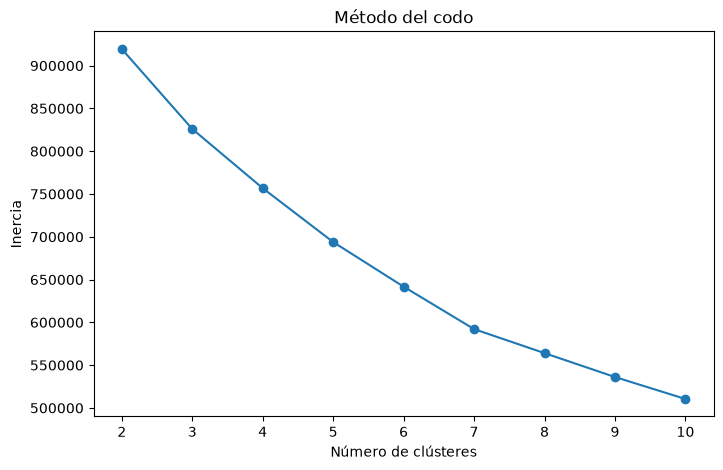

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inercias,
    marker="o"
)

plt.xlabel("Número de clústeres")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.xticks(range(2, 11))
plt.show()

In [12]:

rng = np.random.default_rng()

sample_idx = rng.choice(X_cluster_scaled.shape[0], size=10_000, replace=False)

X_silhouette = X_cluster_scaled[sample_idx]

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, n_init=10)

    labels = kmeans.fit_predict(X_silhouette)

    score = silhouette_score(
        X_silhouette,
        labels
    )

    silhouette_scores.append(score)

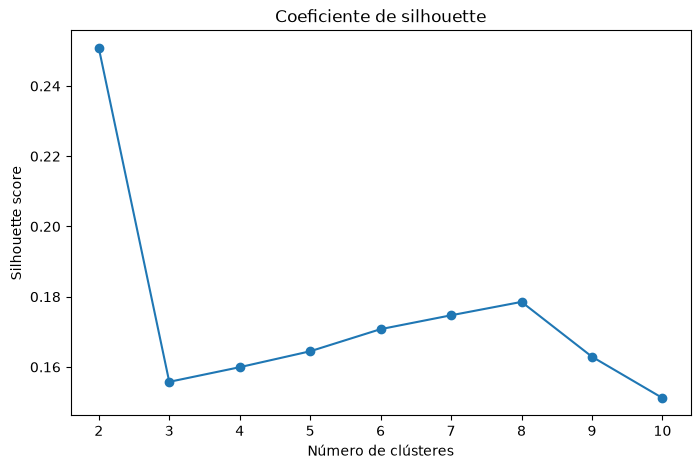

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Número de clústeres")
plt.ylabel("Silhouette score")
plt.title("Coeficiente de silhouette")
plt.xticks(range(2, 11))
plt.show()

El método del codo no presenta un punto de inflexión claramente definido. En cambio, el coeficiente de silhouette alcanza su valor máximo para k = 2, por lo que se seleccionarán 2 clusters para el análisis posterior.

### Construcción del modelo
Con el valor de k seleccionado, se ajusta el modelo de K-Medias para asignar cada canción al clúster correspondiente.

In [14]:
kmeans = KMeans(n_clusters=2, n_init=10)

clusters = kmeans.fit_predict(X_cluster_scaled)

### Perfil de los clusters

Para interpretar los grupos obtenidos, se analizan los centroides de cada clúster. Como las variables fueron estandarizadas, los valores positivos indican que la característica se encuentra por encima del promedio del conjunto de datos, mientras que los valores negativos indican lo contrario.

In [15]:
cluster_centers = pd.DataFrame(kmeans.cluster_centers_, columns=numerical_features)

cluster_centers

,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.028349,0.178327,0.435735,0.380268,0.081556,-0.418029,-0.149597,0.060450,0.196104,0.129856
1,-0.087082,-0.547772,-1.338455,-1.168076,-0.250518,1.284069,0.459521,-0.185686,-0.602377,-0.398883


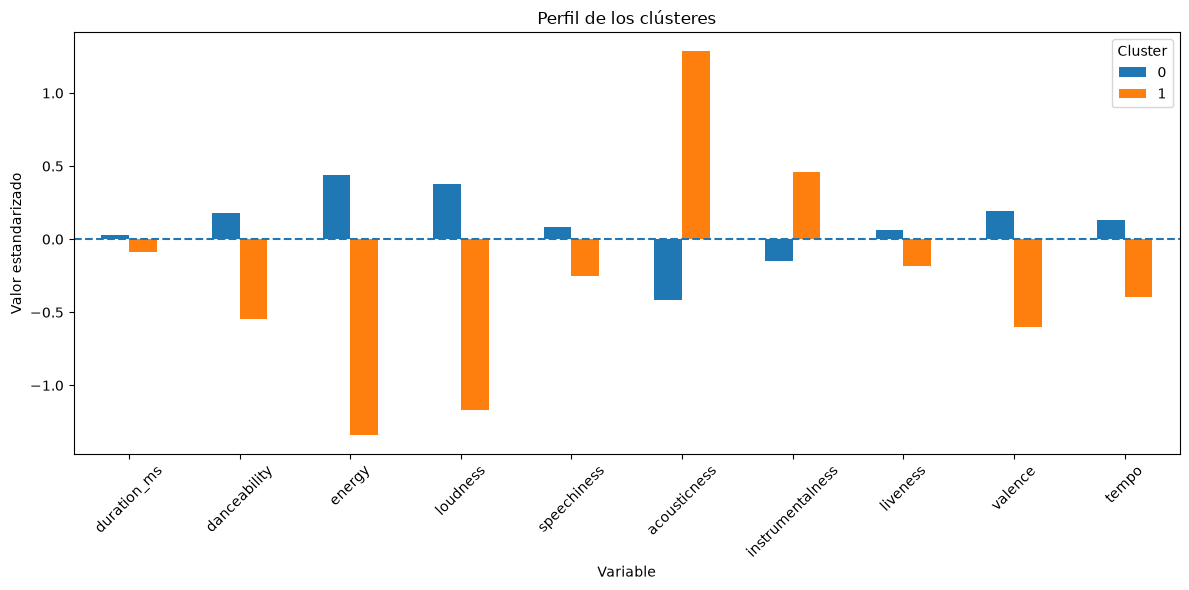

In [16]:
cluster_centers.T.plot(kind="bar", figsize=(12, 6))

plt.axhline(0, linestyle="--")
plt.ylabel("Valor estandarizado")
plt.xlabel("Variable")
plt.title("Perfil de los clústeres")
plt.xticks(rotation=45)
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

Los centroides muestran que el clúster 0 agrupa canciones con mayores valores de energy, loudness, danceability y valence, además de menores niveles de acousticness e instrumentalness. En contraste, el clúster 1 reúne canciones con un perfil más acústico e instrumental, acompañado de menor energía y menor danceability.

### Popularidad por clúster

Como la popularidad no se utilizó para formar los clústeres, se analiza posteriormente para identificar si existen diferencias entre los grupos obtenidos.

In [17]:
kmeans = KMeans(n_clusters=2, n_init=10)
clusters = kmeans.fit_predict(X_cluster_scaled)

df_cluster = df.copy()
df_cluster["cluster"] = clusters

df_cluster.groupby("cluster")["popularity"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
cluster,,,,
0,27928,31.713048,32.0,21.527202
1,86072,33.733514,35.0,22.529651


Ambos clústeres presentan niveles de popularidad similares, aunque el clúster 1 muestra una media y una mediana ligeramente superiores. Esto sugiere que las canciones con un perfil más energético y bailable tienden a presentar una popularidad ligeramente mayor. La diferencia entre ambos es reducida, por lo que la popularidad no parece estar determinada únicamente por estas características musicales.

## 5.5 Exportación de resultados

Se guardan los principales resultados del análisis no supervisado para utilizarlos posteriormente en la aplicación de Shiny.

In [18]:
results_dir = project_root / "results"

pca_variance.to_csv(
    results_dir / "pca_variance.csv",
    index=False
)

pca_coordinates = individuals.copy()

pca_coordinates.columns = [
    f"PC{i + 1}" for i in range(pca_coordinates.shape[1])
]

pca_coordinates.to_csv(
    results_dir / "pca_coordinates.csv",
    index=False
)

pca_correlations = variables.copy()

pca_correlations.columns = [
    f"PC{i + 1}" for i in range(pca_correlations.shape[1])
]

pca_correlations.index.name = "variable"

pca_correlations.to_csv(
    results_dir / "pca_correlations.csv"
)

clustering_metrics = pd.DataFrame({
    "k": range(2, 11),
    "inertia": inercias,
    "silhouette": silhouette_scores
})

clustering_metrics.to_csv(
    results_dir / "clustering_metrics.csv",
    index=False
)

cluster_profiles = cluster_centers.copy()
cluster_profiles.index.name = "cluster"

cluster_profiles.to_csv(
    results_dir / "cluster_profiles.csv"
)

df_cluster.to_csv(
    results_dir / "clustered_data.csv",
    index=False
)

popularity_by_cluster = (
    df_cluster
    .groupby("cluster")["popularity"]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

popularity_by_cluster.to_csv(
    results_dir / "popularity_by_cluster.csv",
    index=False
)